In [1]:
import os
import random
import numpy as np
import pandas as pd
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
import gc 
import time
import copy
import math
from torchvision.transforms import RandAugment
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from xgboost import XGBClassifier

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchinfo
from torchinfo import summary
from torch.utils.data import Dataset, DataLoader
from torch.utils.data import WeightedRandomSampler
from torchvision import transforms
from torchvision import models
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report, accuracy_score, f1_score, cohen_kappa_score, roc_auc_score, precision_score, recall_score
from PIL import Image


import hashlib
import shutil
import ssl
import tempfile
import warnings
from pathlib import Path
from urllib.error import URLError
from urllib.parse import urlparse
from urllib.request import HTTPSHandler, Request, build_opener

import torch
import torch.nn as nn
from torch.hub import get_dir as get_torch_hub_dir
from torchvision import models
from torchvision.models import VGG16_Weights, vgg16

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

In [2]:

base_path = 'LungHist700_combined/data/'
csv_path = base_path + 'data.csv'
images_base = base_path + 'images/' 

batch_size = 32
num_epochs = 100
learning_rate = 3e-4
random_seed = 42

def seed_everything(seed):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)

seed_everything(random_seed)


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Dispositivo em uso: {device}\n")

full_df = pd.read_csv(csv_path)
superclass_map = {'aca': 0, 'ssc': 1, 'scc': 1, 'nor': 2}
full_df['label'] = full_df['superclass'].map(superclass_map)

print("Dados carregados e mapeados com sucesso!")
print("Total de linhas:", len(full_df))
print("Colunas:", full_df.columns.tolist())
print("Exemplo das 5 primeiras linhas:\n", full_df.head())
print("Distribuição de resolução:\n", full_df['resolution'].value_counts())


print("Função de processamento de dados atualizada!")

Dispositivo em uso: cpu

Dados carregados e mapeados com sucesso!
Total de linhas: 691
Colunas: ['superclass', 'subclass', 'resolution', 'image_id', 'patient_id', 'label']
Exemplo das 5 primeiras linhas:
   superclass subclass resolution  image_id  patient_id  label
0        aca       bd        40x       901           1      0
1        aca       bd        40x       902           1      0
2        aca       bd        40x       903           1      0
3        aca       bd        40x       904           1      0
4        aca       bd        40x       905           1      0
Distribuição de resolução:
 resolution
20x    359
40x    332
Name: count, dtype: int64
Função de processamento de dados atualizada!


In [3]:
class LungHistDataset(Dataset):

    def __init__(self, dataframe, root_dir, transform=None):

        self.df = dataframe
        self.root_dir = root_dir
        self.transform = transform

    def __len__(self):

        return len(self.df)

    def __getitem__(self, idx):

        row = self.df.iloc[idx]

        superclass = row['superclass']
        image_id = row['image_id']
        resolution = row['resolution']

        subclass = (
            row['subclass']
            if not pd.isna(row['subclass'])
            else ""
        )

        file_prefix = superclass

        if superclass == 'scc':

            folder_name = 'ssc'
            file_prefix = 'ssc'

        else:

            folder_name = superclass

        class_dir = os.path.join(
            self.root_dir,
            folder_name
        )

        potential_filenames = [

            f"{image_id}.jpg",

            f"{file_prefix}_{subclass}_{resolution}_{image_id}.jpg",

            f"{file_prefix}_{resolution}_{image_id}.jpg",

            f"{image_id}.png",

            f"{file_prefix}_{subclass}_{resolution}_{image_id}.png",

            f"{file_prefix}_{resolution}_{image_id}.png"
        ]

        img_path = None

        for fname in potential_filenames:

            full_path = os.path.join(
                class_dir,
                fname
            )

            if os.path.exists(full_path):

                img_path = full_path
                break

        if img_path is None and os.path.exists(class_dir):

            import glob

            search_pattern = os.path.join(
                class_dir,
                f"*{image_id}.*"
            )

            found_files = glob.glob(search_pattern)

            if found_files:

                img_path = found_files[0]

        try:

            if img_path is None:

                raise FileNotFoundError(
                    "Imagem não encontrada"
                )

            image = Image.open(img_path).convert("RGB")

        except Exception as e:

            print("\n" + "=" * 60)
            print("ERRO AO CARREGAR IMAGEM")
            print("=" * 60)

            print(f"ID: {image_id}")
            print(f"Classe: {superclass}")
            print(f"Resolution: {resolution}")
            print(f"Pasta: {class_dir}")
            print(f"Path encontrado: {img_path}")
            print(f"Erro: {e}")

            image = Image.new('RGB', (224, 224))

        label = row['label']

        if self.transform:

            image = self.transform(image)

        return image, label


print("✓ Classe Dataset definida com sucesso!")

✓ Classe Dataset definida com sucesso!


In [4]:
train_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


val_test_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print("Sem data aug configurado com sucesso.")

Sem data aug configurado com sucesso.


In [5]:
def print_stats_table(df_name, train_df, val_df, test_df):
    c_train = train_df['label'].value_counts().to_dict()
    c_val   = val_df['label'].value_counts().to_dict()
    c_test  = test_df['label'].value_counts().to_dict()
    idx_to_class = {0: 'ACA', 1: 'SCC', 2: 'NOR'}
    
    print(f"\nCONJUNTO DE DADOS: {df_name}")
    print("-" * 42)
    print(f"{'CLASSE':<8} | {'TREINO':<8} | {'VALIDAÇÃO':<8} | {'TESTE':<8}")
    print("-" * 42)
    for idx in range(3): 
        name = idx_to_class[idx]
        print(f"{name:<8} | {c_train.get(idx, 0):<8} | {c_val.get(idx, 0):<8} | {c_test.get(idx, 0):<8}")
    print("-" * 42 + "\n")

print("Função print_stats_table definida com sucesso!")

Função print_stats_table definida com sucesso!


In [6]:

def get_reproducible_ids(df, resolution):

    if resolution == '20x':
        train_ids = [2,3,4,5,7,8,12,14,15,16,17,18,20,21,23,24,25,26,28,29,30,33,36,37,38,39,41,42,45]
        val_ids   = [1,6,27,32,44]
        test_ids  = [9,13,31,40]

    elif resolution == '40x':
        train_ids = [2,6,8,9,10,12,13,14,16,18,19,21,22,24,28,29,31,33,34,35,36,38,40,44]
        val_ids   = [1,4,17,26,30,37,45]
        test_ids  = [11,15,20,25,32,43]

    else:
        raise ValueError("Resolution deve ser '20x' ou '40x'")

    train_df = df[df['patient_id'].isin(train_ids)]
    val_df   = df[df['patient_id'].isin(val_ids)]
    test_df  = df[df['patient_id'].isin(test_ids)]

    return train_df, val_df, test_df



def process_resolution(res):

    print(f"\n====================== {res.upper()} ======================")

   
    df_res = full_df[
        (full_df['resolution'] == res) &
        (full_df['superclass'].isin(['aca', 'nor', 'scc']))
    ].reset_index(drop=True)

    print(f"Dataset {res}: {len(df_res)} imagens")
    
    train_df, val_df, test_df = get_reproducible_ids(df_res, res)

    
    train_df = train_df.reset_index(drop=True)
    val_df   = val_df.reset_index(drop=True)
    test_df  = test_df.reset_index(drop=True)

  
    print("\n Classes por split:")
    for name, df_split in [("train", train_df), ("val", val_df), ("test", test_df)]:
        print(f"\n{name.upper()}")
        print(df_split["superclass"].value_counts())

    print("\n🔎 Verificação de leakage:")
    print("train ∩ val :", set(train_df['patient_id']) & set(val_df['patient_id']))
    print("train ∩ test:", set(train_df['patient_id']) & set(test_df['patient_id']))
    print("val ∩ test :", set(val_df['patient_id']) & set(test_df['patient_id']))


    train_ds = LungHistDataset(train_df, images_base, transform=train_transform)
    val_ds   = LungHistDataset(val_df,   images_base, transform=val_test_transform)
    test_ds  = LungHistDataset(test_df,  images_base, transform=val_test_transform)


    train_loader = DataLoader(
        train_ds,
        batch_size=batch_size,
        shuffle=False,
        num_workers=4,
        pin_memory=True,
        persistent_workers=False
    )

    val_loader = DataLoader(
        val_ds,
        batch_size=batch_size,
        shuffle=False,
        num_workers=4,
        pin_memory=True,
        persistent_workers=False
    )

    test_loader = DataLoader(
        test_ds,
        batch_size=batch_size,
        shuffle=False,
        num_workers=4,
        pin_memory=True,
        persistent_workers=False
    )

    print_stats_table(f"{res.upper()} (SPLIT FIXO POR PACIENTE)", train_df, val_df, test_df)

    return train_loader, val_loader, test_loader


train_loader_20x, val_loader_20x, test_loader_20x = process_resolution('20x')
train_loader_40x, val_loader_40x, test_loader_40x = process_resolution('40x')


====================== 20X ======================
Dataset 20x: 359 imagens

 Classes por split:

TRAIN
superclass
aca    109
scc    102
nor     52
Name: count, dtype: int64

VAL
superclass
aca    19
scc    15
nor    14
Name: count, dtype: int64

TEST
superclass
nor    19
aca    18
scc    11
Name: count, dtype: int64

🔎 Verificação de leakage:
train ∩ val : set()
train ∩ test: set()
val ∩ test : set()

CONJUNTO DE DADOS: 20X (SPLIT FIXO POR PACIENTE)
------------------------------------------
CLASSE   | TREINO   | VALIDAÇÃO | TESTE   
------------------------------------------
ACA      | 109      | 19       | 18      
SCC      | 102      | 15       | 11      
NOR      | 52       | 14       | 19      
------------------------------------------


====================== 40X ======================
Dataset 40x: 332 imagens

 Classes por split:

TRAIN
superclass
aca    101
scc     96
nor     39
Name: count, dtype: int64

VAL
superclass
aca    16
scc    16
nor    14
Name: count, dtype: int64


In [7]:
def get_model(model_name, num_classes=3, feature_extract=True):
    model = None

    if model_name == 'resnet50':
        weights = models.ResNet50_Weights.DEFAULT
        model = models.resnet50(weights=weights)

        if feature_extract:
            for param in model.parameters():
                param.requires_grad = False

        num_ftrs = model.fc.in_features
        model.fc = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(num_ftrs, num_classes)
        )

    elif model_name == 'efficientnet_b0':
        weights = models.EfficientNet_B0_Weights.DEFAULT
        model = models.efficientnet_b0(weights=weights)

        if feature_extract:
            for param in model.parameters():
                param.requires_grad = False

        num_ftrs = model.classifier[1].in_features
        model.classifier = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(num_ftrs, num_classes)
        )

    elif model_name == 'efficientnet_b3':
        weights = models.EfficientNet_B3_Weights.DEFAULT
        model = models.efficientnet_b3(weights=weights)

        if feature_extract:
            for param in model.parameters():
                param.requires_grad = False

        num_ftrs = model.classifier[1].in_features
        model.classifier = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(num_ftrs, num_classes)
        )

    elif model_name == 'densenet121':
        weights = models.DenseNet121_Weights.DEFAULT
        model = models.densenet121(weights=weights)

        if feature_extract:
            for param in model.parameters():
                param.requires_grad = False

        num_ftrs = model.classifier.in_features
        model.classifier = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(num_ftrs, num_classes)
        )

    elif model_name == 'convnext_tiny':

        weights = models.ConvNeXt_Tiny_Weights.DEFAULT
        model = models.convnext_tiny(weights=weights)

        if feature_extract:
            for param in model.parameters():
                param.requires_grad = False

       
        num_ftrs = model.classifier[2].in_features

        model.classifier[2] = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(num_ftrs, num_classes)
        )

        # libera apenas o classifier
        for param in model.classifier.parameters():
            param.requires_grad = True

    elif model_name == 'vit_b16':

        weights = models.ViT_B_16_Weights.DEFAULT
        model = models.vit_b_16(weights=weights)

        # congela tudo
        for param in model.parameters():
            param.requires_grad = False

        # libera últimas camadas do encoder
        for param in model.encoder.layers[-4:].parameters():
            param.requires_grad = True

        # cabeça
        num_ftrs = model.heads.head.in_features

        model.heads.head = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(num_ftrs, num_classes)
        )

        for param in model.heads.parameters():
            param.requires_grad = True
    return model.to(device)

In [8]:
import torch

def load_model(model_path, num_classes=3):

    name = model_path.lower()

    if "resnet50" in name:
        model_name = "resnet50"
    elif "densenet121" in name:
        model_name = "densenet121"
    elif "efficientnet_b3" in name:
        model_name = "efficientnet_b3"
    elif "convnext_tiny" in name:
        model_name = "convnext_tiny"
    elif "vit_b16" in name:
        model_name = "vit_b16"
    else:
        raise ValueError(f"Modelo não reconhecido: {model_path}")

   
    model = get_model(
        model_name,
        num_classes=num_classes,
        feature_extract=False  # importante!
    )

    state_dict = torch.load(model_path, map_location=device)

    model.load_state_dict(state_dict)

    model.to(device)
    model.eval()

    return model

In [9]:
import os

def load_all_models(path):
    models_20x = {}
    models_40x = {}

    for file in os.listdir(path):
        if file.endswith(".pth"):
            full_path = os.path.join(path, file)

            model = load_model(full_path)

            if "20x" in file:
                models_20x[file.replace(".pth", "")] = model
            elif "40x" in file:
                models_40x[file.replace(".pth", "")] = model

    return models_20x, models_40x


In [ ]:
path = "Best_models_Rand"

models_20x, models_40x = load_all_models(path)


models_list_40x = [
    models_40x['best_Rand_resnet50_40x'],
    models_40x['best_Rand_efficientnet_b3_40x'],
    models_40x['best_Rand_densenet121_40x'],
    models_40x['best_Rand_vit_b16_40x'],
    models_40x['best_Rand_convnext_tiny_40x']
]

models_list_20x = [
    models_20x['best_Rand_resnet50_20x'],
    models_20x['best_Rand_efficientnet_b3_20x'],
    models_20x['best_Rand_densenet121_20x'],
    models_20x['best_Rand_vit_b16_20x'],
    models_20x['best_Rand_convnext_tiny_20x']
]



In [11]:
import torch
from collections import Counter

def hard_voting(models, images):

    preds = []

    for model in models:
        outputs = model(images)
        pred = torch.argmax(outputs, dim=1)
        preds.append(pred)

    preds = torch.stack(preds)

    final_preds = []

    for i in range(images.size(0)):
        votes = preds[:, i].tolist()
        majority = Counter(votes).most_common(1)[0][0]
        final_preds.append(majority)

    return torch.tensor(final_preds, device=images.device)

In [12]:
import torch.nn.functional as F

def soft_voting(models, images):

    probs_sum = None

    for model in models:

        outputs = model(images)
        probs = F.softmax(outputs, dim=1)

        if probs_sum is None:
            probs_sum = probs
        else:
            probs_sum += probs

    probs_mean = probs_sum / len(models)

    preds = torch.argmax(probs_mean, dim=1)

    return preds, probs_mean

In [ ]:
def compute_weights_from_accuracy(accuracies, device):
    weights = torch.tensor(accuracies, dtype=torch.float32, device=device)
    weights = weights / weights.sum()
    return weights


# pesos = best val acc

accuracies_20x = [
    0.9166666666666666,  # resnet50
    0.9166666666666666,  # efficientnet_b3
    0.8958333333333334,  # densenet121
    0.8333333333333334,  # vit_b16
    0.9583333333333334   # convnext_tiny
]

accuracies_40x = [
    0.8913043478260869,  # resnet50
    0.8260869565217391,  # efficientnet_b3
    0.9130434782608695,  # densenet121
    0.8260869565217391,  # vit_b16
    0.9347826086956522   # convnext_tiny
]



weights_20x = compute_weights_from_accuracy(accuracies_20x, device)
weights_40x = compute_weights_from_accuracy(accuracies_40x, device)

print("Pesos 20x:")
print(weights_20x)

print("\nPesos 40x:")
print(weights_40x)

Pesos 20x:
tensor([0.2028, 0.2028, 0.1982, 0.1843, 0.2120])

Pesos 40x:
tensor([0.2030, 0.1881, 0.2079, 0.1881, 0.2129])


In [14]:
def weighted_average_voting(models, weights, images):

    weighted_probs = None

    for model, w in zip(models, weights):

        logits = model(images)
        probs = F.softmax(logits, dim=1)

        weighted_output = w * probs

        if weighted_probs is None:
            weighted_probs = weighted_output
        else:
            weighted_probs += weighted_output

    final_probs = weighted_probs
    final_preds = torch.argmax(final_probs, dim=1)

    return final_preds, final_probs

In [15]:
def evaluate_resolutions(
    models_20x, models_40x,
    weights_20x, weights_40x,
    images_20x, images_40x
):

    results = {}

    results["20x"] = {}

    preds_20x_hard, _ = hard_voting(models_20x, images_20x)
    results["20x"]["hard"] = preds_20x_hard

    preds_20x_soft, _ = soft_voting(models_20x, images_20x)
    results["20x"]["soft"] = preds_20x_soft

    preds_20x_weighted, _ = weighted_average_voting(
        models_20x,
        weights_20x,
        images_20x
    )
    results["20x"]["weighted"] = preds_20x_weighted

    results["40x"] = {}

    preds_40x_hard, _ = hard_voting(models_40x, images_40x)
    results["40x"]["hard"] = preds_40x_hard

    preds_40x_soft, _ = soft_voting(models_40x, images_40x)
    results["40x"]["soft"] = preds_40x_soft

    preds_40x_weighted, _ = weighted_average_voting(
        models_40x,
        weights_40x,
        images_40x
    )
    results["40x"]["weighted"] = preds_40x_weighted

    return results

In [16]:
def evaluate_ensemble(
    models,
    dataloader,
    voting="hard",
    weights=None,
    num_classes=3,
    device="cuda"
):

    all_preds = []
    all_labels = []
    all_probs = []

    for images, labels in dataloader:

        images = images.to(device)
        labels = labels.to(device)

        with torch.no_grad():

            if voting == "hard":

                preds = hard_voting(models, images)

                probs = torch.zeros(
                    (images.size(0), num_classes),
                    device=device
                )
                probs.scatter_(1, preds.unsqueeze(1), 1.0)

            elif voting == "soft":

                preds, probs = soft_voting(models, images)

            elif voting == "weighted":

                if weights is None:
                    raise ValueError(
                        "weights required for weighted voting"
                    )

                preds, probs = weighted_average_voting(
                    models,
                    weights,
                    images
                )

            else:
                raise ValueError(
                    "voting must be 'hard', 'soft' or 'weighted'"
                )

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

    acc = accuracy_score(all_labels, all_preds)

    f1 = f1_score(
        all_labels,
        all_preds,
        average="macro"
    )

    kappa = cohen_kappa_score(
        all_labels,
        all_preds
    )

    try:
        auc = roc_auc_score(
            all_labels,
            np.array(all_probs),
            multi_class="ovr"
        )
    except:
        auc = 0.0

    return acc, auc, kappa, f1

In [17]:
import torch
import torch.nn.functional as F
import numpy as np
from sklearn.metrics import accuracy_score, f1_score, cohen_kappa_score, roc_auc_score


def evaluate_single_resolution(models, dataloader, weights=None, num_classes=3, device="cuda"):

    results = {
        "hard": {"preds": [], "probs": [], "labels": []},
        "soft": {"preds": [], "probs": [], "labels": []},
        "weighted": {"preds": [], "probs": [], "labels": []},
    }

    for images, labels in dataloader:

        images = images.to(device)
        labels = labels.to(device)
        batch_size = images.size(0)

        with torch.no_grad():

            hard_preds = hard_voting(models, images)

            hard_probs = torch.zeros((batch_size, num_classes), device=device)
            hard_probs.scatter_(1, hard_preds.unsqueeze(1), 1.0)

            soft_sum = torch.zeros((batch_size, num_classes), device=device)

            for model in models:
                outputs = model(images)
                soft_sum += F.softmax(outputs, dim=1)

            soft_probs = soft_sum / len(models)
            soft_preds = torch.argmax(soft_probs, dim=1)

            if weights is None:
                raise ValueError("weights required for weighted voting")

            weighted_sum = torch.zeros((batch_size, num_classes), device=device)

            for model, w in zip(models, weights):

                outputs = model(images)
                probs = F.softmax(outputs, dim=1)

                weighted_sum += w * probs

            weighted_probs = weighted_sum
            weighted_preds = torch.argmax(weighted_probs, dim=1)

        for method, preds, probs in [
            ("hard", hard_preds, hard_probs),
            ("soft", soft_preds, soft_probs),
            ("weighted", weighted_preds, weighted_probs),
        ]:
            results[method]["preds"].extend(preds.cpu().numpy())
            results[method]["probs"].extend(probs.cpu().numpy())
            results[method]["labels"].extend(labels.cpu().numpy())

    def compute(y_true, y_pred, y_prob):
        acc = accuracy_score(y_true, y_pred)
        f1 = f1_score(y_true, y_pred, average="macro")
        kappa = cohen_kappa_score(y_true, y_pred)

        try:
            auc = roc_auc_score(
                y_true,
                np.array(y_prob),
                multi_class="ovr"
            )
        except:
            auc = 0.0

        return acc, auc, kappa, f1

    final = {}

    for m in results:
        acc, auc, kappa, f1 = compute(
            results[m]["labels"],
            results[m]["preds"],
            results[m]["probs"]
        )

        final[m] = {
            "accuracy": acc,
            "roc_auc": auc,
            "kappa": kappa,
            "f1_macro": f1
        }

    return final

In [18]:
print("\n===== ENSEMBLE 20x =====")

for method in ["hard", "soft", "weighted"]:

    acc, auc, kappa, f1 = evaluate_ensemble(
        models=models_list_20x,
        dataloader=val_loader_20x,
        voting=method,
        weights=weights_20x,
        device=device
    )

    print(
        f"{method.upper()} → "
        f"Acc: {acc:.4f} | "
        f"AUC: {auc:.4f} | "
        f"Kappa: {kappa:.4f} | "
        f"F1: {f1:.4f}"
    )


===== ENSEMBLE 20x =====


/home/joyzinhw/.local/lib/python3.10/site-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


HARD → Acc: 0.9375 | AUC: 0.9558 | Kappa: 0.9058 | F1: 0.9393


/home/joyzinhw/.local/lib/python3.10/site-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


SOFT → Acc: 0.9375 | AUC: 0.9938 | Kappa: 0.9057 | F1: 0.9393


/home/joyzinhw/.local/lib/python3.10/site-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


WEIGHTED → Acc: 0.9375 | AUC: 0.9938 | Kappa: 0.9057 | F1: 0.9393


In [19]:
def get_preds_probs_labels(
    models,
    dataloader,
    voting="hard",
    weights=None,
    num_classes=3,
    device="cuda"
):

    all_preds = []
    all_labels = []
    all_probs = []

    for images, labels in dataloader:

        images = images.to(device)
        labels = labels.to(device)

        with torch.no_grad():

            if voting == "hard":

                preds = hard_voting(models, images)

                probs = torch.zeros(
                    (images.size(0), num_classes),
                    device=device
                )

                probs.scatter_(1, preds.unsqueeze(1), 1.0)

            elif voting == "soft":

                preds, probs = soft_voting(models, images)

            elif voting == "weighted":

                if weights is None:
                    raise ValueError("weights required for weighted voting")

                weighted_sum = torch.zeros(
                    (images.size(0), num_classes),
                    device=device
                )

                for model, w in zip(models, weights):
                    outputs = model(images)
                    weighted_sum += w * outputs

                probs = weighted_sum
                preds = torch.argmax(probs, dim=1)

            else:
                raise ValueError("Invalid voting type")

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

    return (
        np.array(all_labels),
        np.array(all_preds),
        np.array(all_probs)
    )

/home/joyzinhw/.local/lib/python3.10/site-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)



===== HARD =====
[[17  0  2]
 [ 1 14  0]
 [ 0  0 14]]


/home/joyzinhw/.local/lib/python3.10/site-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)



===== SOFT =====
[[17  1  1]
 [ 1 14  0]
 [ 0  0 14]]


/home/joyzinhw/.local/lib/python3.10/site-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)



===== WEIGHTED =====
[[17  1  1]
 [ 1 14  0]
 [ 0  0 14]]

Matrizes salvas em: results_matriz_20

ERROS EM COMUM ENTRE TODOS OS ENSEMBLES

Total: 3

--------------------------------------------------
Imagem índice: 14
TRUE: ACA
HARD → NOR
SOFT → SCC
WEIGHTED → SCC

--------------------------------------------------
Imagem índice: 18
TRUE: ACA
HARD → NOR
SOFT → NOR
WEIGHTED → NOR

--------------------------------------------------
Imagem índice: 29
TRUE: SCC
HARD → ACA
SOFT → ACA
WEIGHTED → ACA


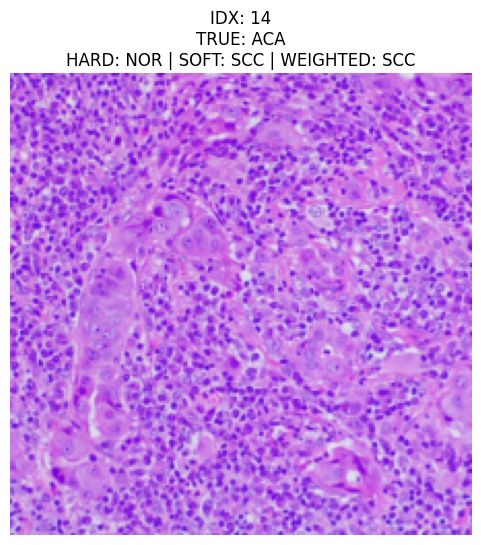

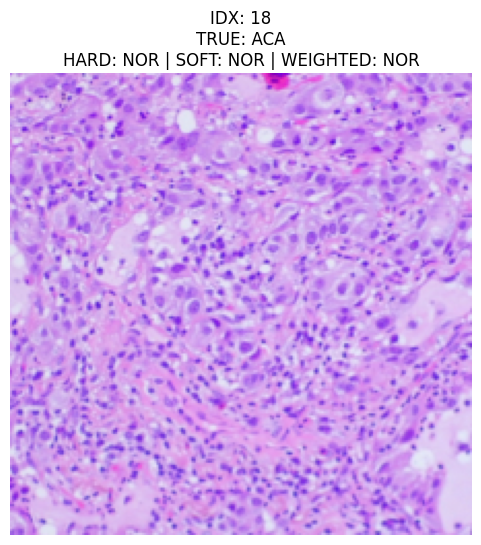

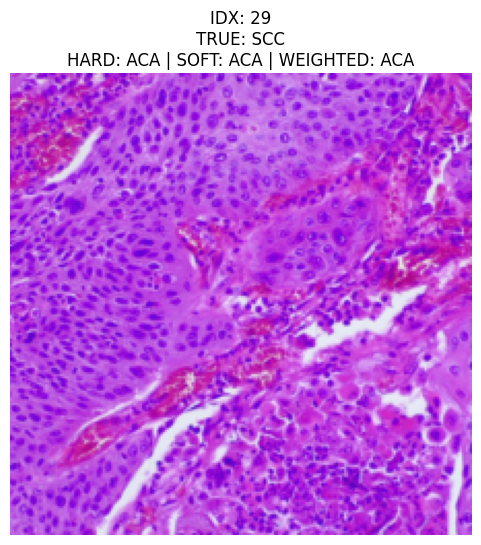


Imagens dos erros em comum salvas em:
results_matriz_20/common_errors


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay
)

SAVE_DIR = "results_matriz_20"

os.makedirs(SAVE_DIR, exist_ok=True)

methods = ["hard", "soft", "weighted"]

ensemble_errors = {}

for method in methods:

    y_true, y_pred, y_probs = get_preds_probs_labels(
        models=models_list_20x,
        dataloader=val_loader_20x,
        voting=method,
        weights=weights_20x,
        device="cpu"
    )

    cm = confusion_matrix(y_true, y_pred)

    print(f"\n===== {method.upper()} =====")

    print(cm)


    np.save(
        os.path.join(SAVE_DIR, f"{method}_confusion_matrix.npy"),
        cm
    )

    fig, ax = plt.subplots(figsize=(6,6))

    disp = ConfusionMatrixDisplay(confusion_matrix=cm)

    disp.plot(ax=ax)

    plt.title(f"Confusion Matrix - {method.upper()}")

    plt.savefig(
        os.path.join(
            SAVE_DIR,
            f"{method}_confusion_matrix.png"
        ),
        bbox_inches="tight"
    )

    plt.close()


    errors = []

    for idx in range(len(y_true)):

        if y_true[idx] != y_pred[idx]:

            errors.append({
                "idx": idx,
                "true": y_true[idx],
                "pred": y_pred[idx]
            })

    ensemble_errors[method] = errors

print("\nMatrizes salvas em:", SAVE_DIR)


hard_errors = set(
    e["idx"] for e in ensemble_errors["hard"]
)

soft_errors = set(
    e["idx"] for e in ensemble_errors["soft"]
)

weighted_errors = set(
    e["idx"] for e in ensemble_errors["weighted"]
)

common_errors = (
    hard_errors
    & soft_errors
    & weighted_errors
)

print("\n" + "="*70)

print("ERROS EM COMUM ENTRE TODOS OS ENSEMBLES")

print("="*70)

print(f"\nTotal: {len(common_errors)}")


class_names = {
    0: "ACA",
    1: "SCC",
    2: "NOR"
}

for idx in sorted(common_errors):

    hard_case = next(
        e for e in ensemble_errors["hard"]
        if e["idx"] == idx
    )

    print("\n" + "-"*50)

    print(f"Imagem índice: {idx}")

    print(
        f"TRUE: {class_names[hard_case['true']]}"
    )

    print(
        f"HARD → {class_names[hard_case['pred']]}"
    )

    soft_case = next(
        e for e in ensemble_errors["soft"]
        if e["idx"] == idx
    )

    print(
        f"SOFT → {class_names[soft_case['pred']]}"
    )

    weighted_case = next(
        e for e in ensemble_errors["weighted"]
        if e["idx"] == idx
    )

    print(
        f"WEIGHTED → {class_names[weighted_case['pred']]}"
    )


import torch

# pega dataset original
dataset = val_loader_20x.dataset

SAVE_COMMON = os.path.join(SAVE_DIR, "common_errors")

os.makedirs(SAVE_COMMON, exist_ok=True)

for idx in sorted(common_errors):


    image, label = dataset[idx]

  
    img = image.permute(1, 2, 0).numpy()

    # normaliza para visualização
    img = (img - img.min()) / (img.max() - img.min())

    hard_case = next(
        e for e in ensemble_errors["hard"]
        if e["idx"] == idx
    )

    soft_case = next(
        e for e in ensemble_errors["soft"]
        if e["idx"] == idx
    )

    weighted_case = next(
        e for e in ensemble_errors["weighted"]
        if e["idx"] == idx
    )

    true_label = class_names[hard_case["true"]]

    hard_pred = class_names[hard_case["pred"]]
    soft_pred = class_names[soft_case["pred"]]
    weighted_pred = class_names[weighted_case["pred"]]


    plt.figure(figsize=(6,6))

    plt.imshow(img)

    plt.axis("off")

    plt.title(
        f"IDX: {idx}\n"
        f"TRUE: {true_label}\n"
        f"HARD: {hard_pred} | "
        f"SOFT: {soft_pred} | "
        f"WEIGHTED: {weighted_pred}"
    )
    save_path = os.path.join(
        SAVE_COMMON,
        f"error_{idx}.png"
    )

    plt.savefig(save_path, bbox_inches="tight")

    plt.show()

    plt.close()

print("\nImagens dos erros em comum salvas em:")
print(SAVE_COMMON)

In [21]:
print("\n===== ENSEMBLE 40x =====")

for method in ["hard", "soft", "weighted"]:

    acc, auc, kappa, f1 = evaluate_ensemble(
        models=models_list_40x,
        dataloader=val_loader_40x,
        voting=method,
        weights=weights_40x,
        device=device
    )

    print(
        f"{method.upper()} → "
        f"Acc: {acc:.4f} | "
        f"AUC: {auc:.4f} | "
        f"Kappa: {kappa:.4f} | "
        f"F1: {f1:.4f}"
    )


===== ENSEMBLE 40x =====


/home/joyzinhw/.local/lib/python3.10/site-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


HARD → Acc: 0.9130 | AUC: 0.9353 | Kappa: 0.8695 | F1: 0.9124


/home/joyzinhw/.local/lib/python3.10/site-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


SOFT → Acc: 0.9130 | AUC: 0.9724 | Kappa: 0.8695 | F1: 0.9124


/home/joyzinhw/.local/lib/python3.10/site-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


WEIGHTED → Acc: 0.9130 | AUC: 0.9738 | Kappa: 0.8695 | F1: 0.9124


/home/joyzinhw/.local/lib/python3.10/site-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)



===== HARD =====
[[14  1  1]
 [ 0 15  1]
 [ 1  0 13]]


/home/joyzinhw/.local/lib/python3.10/site-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)



===== SOFT =====
[[14  1  1]
 [ 0 15  1]
 [ 1  0 13]]


/home/joyzinhw/.local/lib/python3.10/site-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)



===== WEIGHTED =====
[[14  1  1]
 [ 1 14  1]
 [ 1  0 13]]

Matrizes salvas em: results_matriz_40

ERROS EM COMUM ENTRE TODOS OS ENSEMBLES (40X)

Total: 3

--------------------------------------------------
Imagem índice: 9
TRUE: ACA
HARD → SCC
SOFT → SCC
WEIGHTED → SCC

--------------------------------------------------
Imagem índice: 15
TRUE: ACA
HARD → NOR
SOFT → NOR
WEIGHTED → NOR

--------------------------------------------------
Imagem índice: 16
TRUE: SCC
HARD → NOR
SOFT → NOR
WEIGHTED → NOR


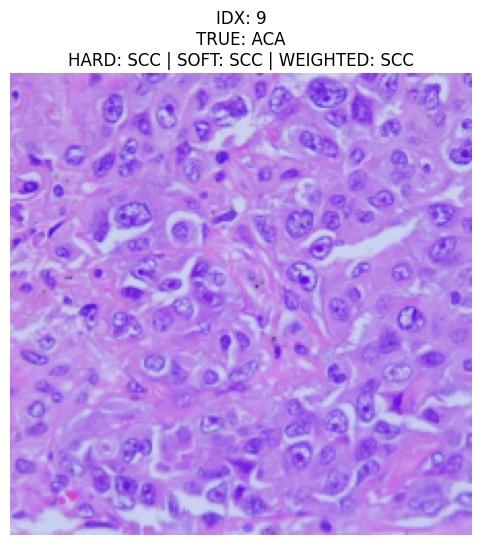

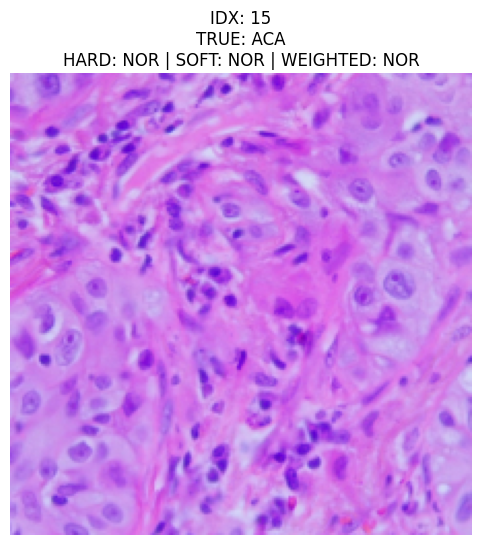

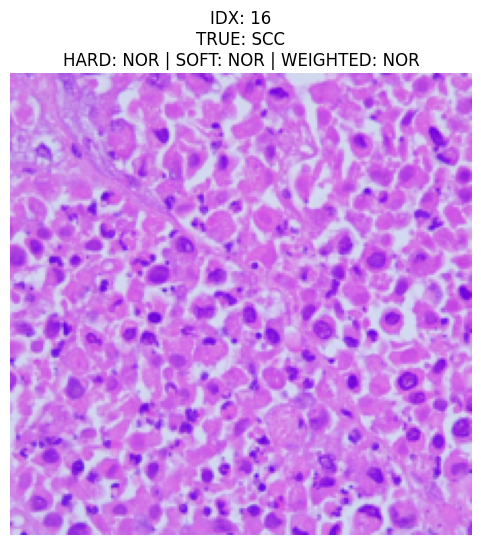


Imagens dos erros em comum salvas em:
results_matriz_40/common_errors


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay
)

SAVE_DIR = "results_matriz_40"

os.makedirs(SAVE_DIR, exist_ok=True)

methods = ["hard", "soft", "weighted"]

ensemble_errors = {}


for method in methods:

    y_true, y_pred, y_probs = get_preds_probs_labels(
        models=models_list_40x,
        dataloader=val_loader_40x,
        voting=method,
        weights=weights_40x,
        device="cpu"
    )

    cm = confusion_matrix(y_true, y_pred)

    print(f"\n===== {method.upper()} =====")

    print(cm)


    np.save(
        os.path.join(SAVE_DIR, f"{method}_confusion_matrix.npy"),
        cm
    )

    fig, ax = plt.subplots(figsize=(6,6))

    disp = ConfusionMatrixDisplay(confusion_matrix=cm)

    disp.plot(ax=ax)

    plt.title(f"Confusion Matrix - {method.upper()}")

    plt.savefig(
        os.path.join(
            SAVE_DIR,
            f"{method}_confusion_matrix.png"
        ),
        bbox_inches="tight"
    )

    plt.close()


    errors = []

    for idx in range(len(y_true)):

        if y_true[idx] != y_pred[idx]:

            errors.append({
                "idx": idx,
                "true": y_true[idx],
                "pred": y_pred[idx]
            })

    ensemble_errors[method] = errors

print("\nMatrizes salvas em:", SAVE_DIR)


hard_errors = set(
    e["idx"] for e in ensemble_errors["hard"]
)

soft_errors = set(
    e["idx"] for e in ensemble_errors["soft"]
)

weighted_errors = set(
    e["idx"] for e in ensemble_errors["weighted"]
)

common_errors = (
    hard_errors
    & soft_errors
    & weighted_errors
)

print("\n" + "="*70)

print("ERROS EM COMUM ENTRE TODOS OS ENSEMBLES (40X)")

print("="*70)

print(f"\nTotal: {len(common_errors)}")

class_names = {
    0: "ACA",
    1: "SCC",
    2: "NOR"
}

for idx in sorted(common_errors):

    hard_case = next(
        e for e in ensemble_errors["hard"]
        if e["idx"] == idx
    )

    print("\n" + "-"*50)

    print(f"Imagem índice: {idx}")

    print(
        f"TRUE: {class_names[hard_case['true']]}"
    )

    print(
        f"HARD → {class_names[hard_case['pred']]}"
    )

    soft_case = next(
        e for e in ensemble_errors["soft"]
        if e["idx"] == idx
    )

    print(
        f"SOFT → {class_names[soft_case['pred']]}"
    )

    weighted_case = next(
        e for e in ensemble_errors["weighted"]
        if e["idx"] == idx
    )

    print(
        f"WEIGHTED → {class_names[weighted_case['pred']]}"
    )



import torch

# pega dataset original
dataset = val_loader_40x.dataset

SAVE_COMMON = os.path.join(SAVE_DIR, "common_errors")

os.makedirs(SAVE_COMMON, exist_ok=True)

for idx in sorted(common_errors):


    image, label = dataset[idx]

    # tensor -> numpy
    img = image.permute(1, 2, 0).numpy()

    # normaliza para visualização
    img = (img - img.min()) / (img.max() - img.min())

    hard_case = next(
        e for e in ensemble_errors["hard"]
        if e["idx"] == idx
    )

    soft_case = next(
        e for e in ensemble_errors["soft"]
        if e["idx"] == idx
    )

    weighted_case = next(
        e for e in ensemble_errors["weighted"]
        if e["idx"] == idx
    )

    true_label = class_names[hard_case["true"]]

    hard_pred = class_names[hard_case["pred"]]
    soft_pred = class_names[soft_case["pred"]]
    weighted_pred = class_names[weighted_case["pred"]]


    plt.figure(figsize=(6,6))

    plt.imshow(img)

    plt.axis("off")

    plt.title(
        f"IDX: {idx}\n"
        f"TRUE: {true_label}\n"
        f"HARD: {hard_pred} | "
        f"SOFT: {soft_pred} | "
        f"WEIGHTED: {weighted_pred}"
    )

    save_path = os.path.join(
        SAVE_COMMON,
        f"error_{idx}.png"
    )

    plt.savefig(save_path, bbox_inches="tight")

    plt.show()

    plt.close()

print("\nImagens dos erros em comum salvas em:")
print(SAVE_COMMON)